# Dense Linear Probe: Pixel-Level Cardiac Segmentation with DINOv3 on ACDC

This notebook implements the DINOv3 paper's **linear evaluation protocol** for semantic segmentation
on the full ACDC cardiac MRI dataset (100 train / 50 test patients).

**Architecture**: Frozen DINOv3 ViT-S/16 backbone → multi-layer feature concatenation →
bilinear upsample → per-pixel 1×1 Conv2d (4 classes: BG, RV, MYO, LV).

**Key differences from patch-level baseline** (`acdc_segmentation.ipynb`):
- Predictions at **full 192×192 pixel resolution** (not blocky 16×16 patches)
- Uses **multiple intermediate layers** (not just the last one)
- Trained with **Dice + CrossEntropy** loss (handles class imbalance)
- Evaluates on the **full ACDC dataset** (100 train + 50 test patients)

**Development backbone**: `dinov3_vits16` (~21M params) — lightweight for MacBook Pro.
To swap to `dinov3_vitb16` or `dinov3_vitl16`, change `MODEL_NAME` and re-run feature caching.

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from monai.transforms import ScaleIntensityd
from cinema.segmentation.dataset import EndDiastoleEndSystoleDataset
from torch.utils.data import DataLoader
from tqdm import tqdm

from heartfm_evals.dense_linear_probe import (
    MODEL_CONFIGS,
    NUM_CLASSES,
    CLASS_NAMES,
    CLASS_COLORS,
    IMAGE_SIZE,
    DenseLinearProbe,
    CombinedLoss,
    CachedFeatureDataset,
    cache_features,
    train_one_epoch,
    evaluate,
    dice_score,
    overlay_labels,
)

In [2]:
# ── Paths ──
ACDC_DATA_DIR = Path("/Users/lbokeria/projects/health_gc/data/heartfm/processed/acdc")
REPO_DIR = "../models/dinov3/"

# ── Backbone selection (change here to swap) ──
MODEL_NAME = "dinov3_vits16"  # lightweight for dev; swap to dinov3_vitb16 for final
WEIGHTS_PATH = f"../model_weights/{MODEL_NAME}.pth"
EMBED_DIM = MODEL_CONFIGS[MODEL_NAME]["embed_dim"]  # 384 for vits16
N_LAYERS = MODEL_CONFIGS[MODEL_NAME]["n_layers"]     # 12

# ── Feature extraction layers ──
LAYER_INDICES = (3, 6, 9, 11)  # 4 evenly-spaced layers

# ── Cache directory (per backbone) ──
CACHE_DIR = Path(f"../feature_cache/{MODEL_NAME}")

# ── Training ──
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-4
N_EPOCHS = 10
PATIENCE = 10

# ── Device ──
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"Using device: {DEVICE}")
print(f"Backbone: {MODEL_NAME} (embed_dim={EMBED_DIM}, layers={N_LAYERS})")
print(f"Selected layers: {LAYER_INDICES} → concat dim = {EMBED_DIM * len(LAYER_INDICES)}")

Using device: mps
Backbone: dinov3_vits16 (embed_dim=384, layers=12)
Selected layers: (3, 6, 9, 11) → concat dim = 1536


## 2. Load ACDC Data (Full Dataset)

In [3]:
train_meta_df = pd.read_csv(ACDC_DATA_DIR / "train_metadata.csv")
test_meta_df = pd.read_csv(ACDC_DATA_DIR / "test_metadata.csv")

print(f"Full training set: {len(train_meta_df)} patients")
print(f"Full test set:     {len(test_meta_df)} patients")
if "pathology" in train_meta_df.columns:
    print(f"\nPathology distribution (train):\n{train_meta_df['pathology'].value_counts().to_string()}")

Full training set: 100 patients
Full test set:     50 patients

Pathology distribution (train):
pathology
DCM     20
HCM     20
MINF    20
NOR     20
RV      20


### Train / Validation Split

Stratified by pathology: 2 patients per group held out for validation
(10 val / 90 train), following the CineMA convention.

In [4]:
if "pathology" in train_meta_df.columns:
    val_pids = (
        train_meta_df.groupby("pathology")
        .sample(n=2, random_state=0)["pid"]
        .tolist()
    )
else:
    # Fallback: random 10% if pathology column is missing
    val_pids = train_meta_df.sample(frac=0.1, random_state=0)["pid"].tolist()

train_split_df = train_meta_df[~train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)
val_split_df   = train_meta_df[train_meta_df["pid"].isin(val_pids)].reset_index(drop=True)

print(f"Train split: {len(train_split_df)} patients")
print(f"Val split:   {len(val_split_df)} patients")
print(f"Test set:    {len(test_meta_df)} patients")
print(f"\nVal patient IDs: {val_pids}")

Train split: 90 patients
Val split:   10 patients
Test set:    50 patients

Val patient IDs: ['patient019', 'patient002', 'patient032', 'patient022', 'patient056', 'patient054', 'patient079', 'patient061', 'patient088', 'patient082']


In [5]:
transform = ScaleIntensityd(keys="sax_image", factor=1 / 255, channel_wise=False)

train_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=train_split_df,
    views="sax",
    transform=transform,
)

val_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "train",
    meta_df=val_split_df,
    views="sax",
    transform=transform,
)

test_cinema = EndDiastoleEndSystoleDataset(
    data_dir=ACDC_DATA_DIR / "test",
    meta_df=test_meta_df,
    views="sax",
    transform=transform,
)

print(f"Train CineMA dataset: {len(train_cinema)} samples")
print(f"Val CineMA dataset:   {len(val_cinema)} samples")
print(f"Test CineMA dataset:  {len(test_cinema)} samples")

Train CineMA dataset: 180 samples
Val CineMA dataset:   20 samples
Test CineMA dataset:  100 samples


In [6]:
train_cinema[0]

{'pid': 'patient001',
 'is_ed': True,
 'sax_width': 192,
 'sax_height': 192,
 'n_slices': 10,
 'sax_image': metatensor([[[[0.0784, 0.1176, 0.7294,  ..., 0.0000, 0.0000, 0.0000],
           [0.0863, 0.1216, 0.7255,  ..., 0.0000, 0.0000, 0.0000],
           [0.1373, 0.1294, 0.7255,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.1451, 0.0941, 0.3020,  ..., 0.0000, 0.0000, 0.0000],
           [0.1373, 0.0980, 0.2706,  ..., 0.0000, 0.0000, 0.0000],
           [0.1294, 0.0980, 0.2353,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0941, 0.0863, 0.7333,  ..., 0.0000, 0.0000, 0.0000],
           [0.0824, 0.0863, 0.7255,  ..., 0.0000, 0.0000, 0.0000],
           [0.1137, 0.0980, 0.7137,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.1333, 0.0980, 0.2353,  ..., 0.0000, 0.0000, 0.0000],
           [0.1255, 0.0980, 0.1882,  ..., 0.0000, 0.0000, 0.0000],
           [0.1176, 0.0980, 0.1490,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.1020, 0.0745, 0.7098,  ..., 0.000

## 3. Load Backbone and Cache Features

Since the backbone is **frozen**, we pre-extract features once and cache to disk.
This avoids re-running the ViT every epoch and makes training very fast (~6K trainable params).

In [7]:
backbone = torch.hub.load(REPO_DIR, MODEL_NAME, source="local", weights=WEIGHTS_PATH)
backbone.eval()
backbone.to(DEVICE)
for p in backbone.parameters():
    p.requires_grad = False
print(f"Loaded {MODEL_NAME} with {sum(p.numel() for p in backbone.parameters()):,} parameters (frozen)")

Loaded dinov3_vits16 with 21,601,152 parameters (frozen)


In [8]:
print("Caching training features...")
train_manifest = cache_features(
    backbone, train_cinema, CACHE_DIR / "train",
    layer_indices=LAYER_INDICES, device=DEVICE,
)

print("\nCaching validation features...")
val_manifest = cache_features(
    backbone, val_cinema, CACHE_DIR / "val",
    layer_indices=LAYER_INDICES, device=DEVICE,
)

print("\nCaching test features...")
test_manifest = cache_features(
    backbone, test_cinema, CACHE_DIR / "test",
    layer_indices=LAYER_INDICES, device=DEVICE,
)

print(f"\nCached: {len(train_manifest)} train, {len(val_manifest)} val, {len(test_manifest)} test slices")

Caching training features...


Caching features: 100%|██████████| 180/180 [00:09<00:00, 19.24it/s]



Caching validation features...


Caching features: 100%|██████████| 20/20 [00:01<00:00, 19.67it/s]



Caching test features...


Caching features: 100%|██████████| 100/100 [00:05<00:00, 18.73it/s]


Cached: 1534 train, 178 val, 916 test slices


In [9]:
# Verify cached feature shapes
sample = torch.load(train_manifest[0]["path"], weights_only=True)
print(f"Feature shape: {sample['features'].shape}")  # expect (embed_dim*4, 12, 12)
print(f"Label shape:   {sample['label'].shape}")      # expect (192, 192)

expected_channels = EMBED_DIM * len(LAYER_INDICES)
assert sample["features"].shape[0] == expected_channels, (
    f"Expected {expected_channels} channels, got {sample['features'].shape[0]}"
)
print("Shape check passed!")

Feature shape: torch.Size([1536, 12, 12])
Label shape:   torch.Size([192, 192])
Shape check passed!


## 4. Create DataLoaders

In [10]:
train_ds = CachedFeatureDataset(train_manifest)
val_ds   = CachedFeatureDataset(val_manifest)
test_ds  = CachedFeatureDataset(test_manifest)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} slices, {len(train_loader)} batches")
print(f"Val:   {len(val_ds)} slices, {len(val_loader)} batches")
print(f"Test:  {len(test_ds)} slices, {len(test_loader)} batches")

Train: 1534 slices, 96 batches
Val:   178 slices, 12 batches
Test:  916 slices, 58 batches


## 5. Define Model, Loss, Optimizer

In [11]:
probe = DenseLinearProbe(
    embed_dim=EMBED_DIM,
    num_classes=NUM_CLASSES,
    layer_indices=LAYER_INDICES,
).to(DEVICE)

criterion = CombinedLoss(ce_weight=1.0, dice_weight=1.0)
optimizer = torch.optim.AdamW(probe.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

n_params = sum(p.numel() for p in probe.parameters() if p.requires_grad)
print(f"Dense linear probe: {n_params:,} trainable parameters")
print(f"Loss: CE + Dice")
print(f"Optimizer: AdamW (lr={LR}, wd={WEIGHT_DECAY})")
print(f"Scheduler: CosineAnnealing (T_max={N_EPOCHS})")

Dense linear probe: 6,148 trainable parameters
Loss: CE + Dice
Optimizer: AdamW (lr=0.001, wd=0.0001)
Scheduler: CosineAnnealing (T_max=10)


## 6. Training Loop

In [12]:
best_val_dice = 0.0
best_epoch = 0
epochs_no_improve = 0
history = {"train_loss": [], "val_macro_dice": [], "lr": []}

for epoch in range(1, N_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(probe, train_loader, criterion, optimizer, DEVICE)
    scheduler.step()

    # Validate
    val_metrics = evaluate(probe, val_loader, DEVICE)
    val_dice = val_metrics["macro_dice"]

    # Record
    history["train_loss"].append(train_loss)
    history["val_macro_dice"].append(val_dice)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # Print every 5 epochs or on improvement
    improved = val_dice > best_val_dice
    if epoch % 5 == 0 or epoch == 1 or improved:
        tag = " *" if improved else ""
        print(
            f"Epoch {epoch:3d}/{N_EPOCHS} | "
            f"loss={train_loss:.4f} | "
            f"val Dice={val_dice:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e}{tag}"
        )

    # Early stopping
    if improved:
        best_val_dice = val_dice
        best_epoch = epoch
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in probe.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val Dice={best_val_dice:.4f} at epoch {best_epoch}.")
            break

# Restore best model
probe.load_state_dict(best_state)
print(f"\nRestored best model from epoch {best_epoch} (val Dice={best_val_dice:.4f})")

Epoch   1/10 | loss=0.8794 | val Dice=0.7471 | lr=9.76e-04 *
Epoch   2/10 | loss=0.4877 | val Dice=0.7793 | lr=9.05e-04 *
Epoch   3/10 | loss=0.4284 | val Dice=0.7886 | lr=7.94e-04 *
Epoch   4/10 | loss=0.3994 | val Dice=0.7946 | lr=6.55e-04 *
Epoch   5/10 | loss=0.3813 | val Dice=0.7975 | lr=5.00e-04 *
Epoch   6/10 | loss=0.3718 | val Dice=0.8005 | lr=3.45e-04 *
Epoch   7/10 | loss=0.3645 | val Dice=0.8018 | lr=2.06e-04 *
Epoch   8/10 | loss=0.3609 | val Dice=0.8029 | lr=9.55e-05 *
Epoch   9/10 | loss=0.3579 | val Dice=0.8030 | lr=2.45e-05 *
Epoch  10/10 | loss=0.3582 | val Dice=0.8031 | lr=0.00e+00 *

Restored best model from epoch 10 (val Dice=0.8031)


### Training Curves

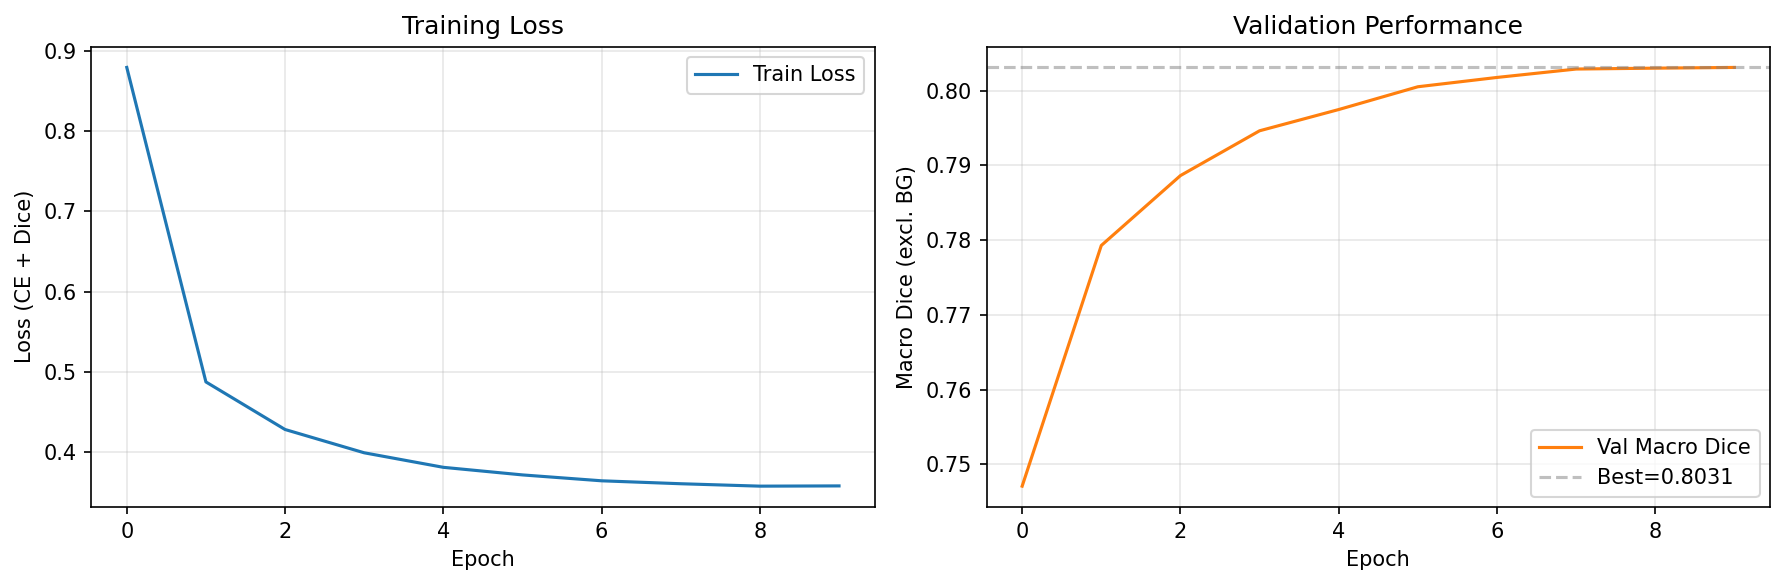

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), dpi=150)

ax1.plot(history["train_loss"], label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (CE + Dice)")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_macro_dice"], label="Val Macro Dice", color="tab:orange")
ax2.axhline(best_val_dice, ls="--", color="gray", alpha=0.5, label=f"Best={best_val_dice:.4f}")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro Dice (excl. BG)")
ax2.set_title("Validation Performance")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Test Set Evaluation

In [14]:
test_metrics = evaluate(probe, test_loader, DEVICE)

print("Per-class Dice scores (test set):")
for name, d in test_metrics["per_class_dice"].items():
    print(f"  {name:>3s}: {d:.4f}")
print(f"\nMacro Dice (excl. BG): {test_metrics['macro_dice']:.4f}")

Per-class Dice scores (test set):
   BG: 0.9843
   RV: 0.7740
  MYO: 0.7086
   LV: 0.8719

Macro Dice (excl. BG): 0.7848


### Per-Patient Dice Scores

In [15]:
# Compute Dice per patient for a clinical breakdown
from heartfm_evals.dense_linear_probe import macro_dice as compute_macro_dice

patient_dices = []

probe.eval()
with torch.inference_mode():
    for i, entry in enumerate(test_manifest):
        data = torch.load(entry["path"], weights_only=True)
        feats = data["features"].unsqueeze(0).to(DEVICE)
        label = data["label"].numpy()

        logits = probe(feats)
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        patient_dices.append({
            "pid": entry["pid"],
            "z_idx": entry["z_idx"],
            "macro_dice": compute_macro_dice(pred, label),
            **{CLASS_NAMES[c]: dice_score(pred, label, c) for c in range(NUM_CLASSES)},
        })

dice_df = pd.DataFrame(patient_dices)
patient_summary = dice_df.groupby("pid")[["macro_dice", "RV", "MYO", "LV"]].mean()
print("Per-patient mean Macro Dice (test set):")
print(patient_summary.round(4).to_string())
print(f"\nOverall mean ± std: {patient_summary['macro_dice'].mean():.4f} ± {patient_summary['macro_dice'].std():.4f}")

Per-patient mean Macro Dice (test set):
            macro_dice      RV     MYO      LV
pid                                           
patient101      0.6594  0.5114  0.6525  0.8142
patient102      0.5103  0.4853  0.5119  0.5336
patient103      0.6845  0.4144  0.7574  0.8816
patient104      0.5806  0.4308  0.7244  0.5866
patient105      0.5502  0.4606  0.6268  0.5632
patient106      0.7310  0.8093  0.5114  0.8723
patient107      0.4696  0.4045  0.3815  0.6228
patient108      0.5291  0.4834  0.5839  0.5201
patient109      0.6893  0.7133  0.5738  0.7809
patient110      0.6528  0.6105  0.6643  0.6837
patient111      0.6594  0.4341  0.7930  0.7510
patient112      0.6245  0.4866  0.5506  0.8362
patient113      0.7054  0.6110  0.6483  0.8568
patient114      0.6014  0.2933  0.7257  0.7854
patient115      0.6362  0.5394  0.5967  0.7725
patient116      0.5692  0.4099  0.6119  0.6858
patient117      0.7071  0.5963  0.6511  0.8739
patient118      0.6413  0.5335  0.5973  0.7930
patient119      0.65

## 8. Visualization — Pixel-Level Predictions

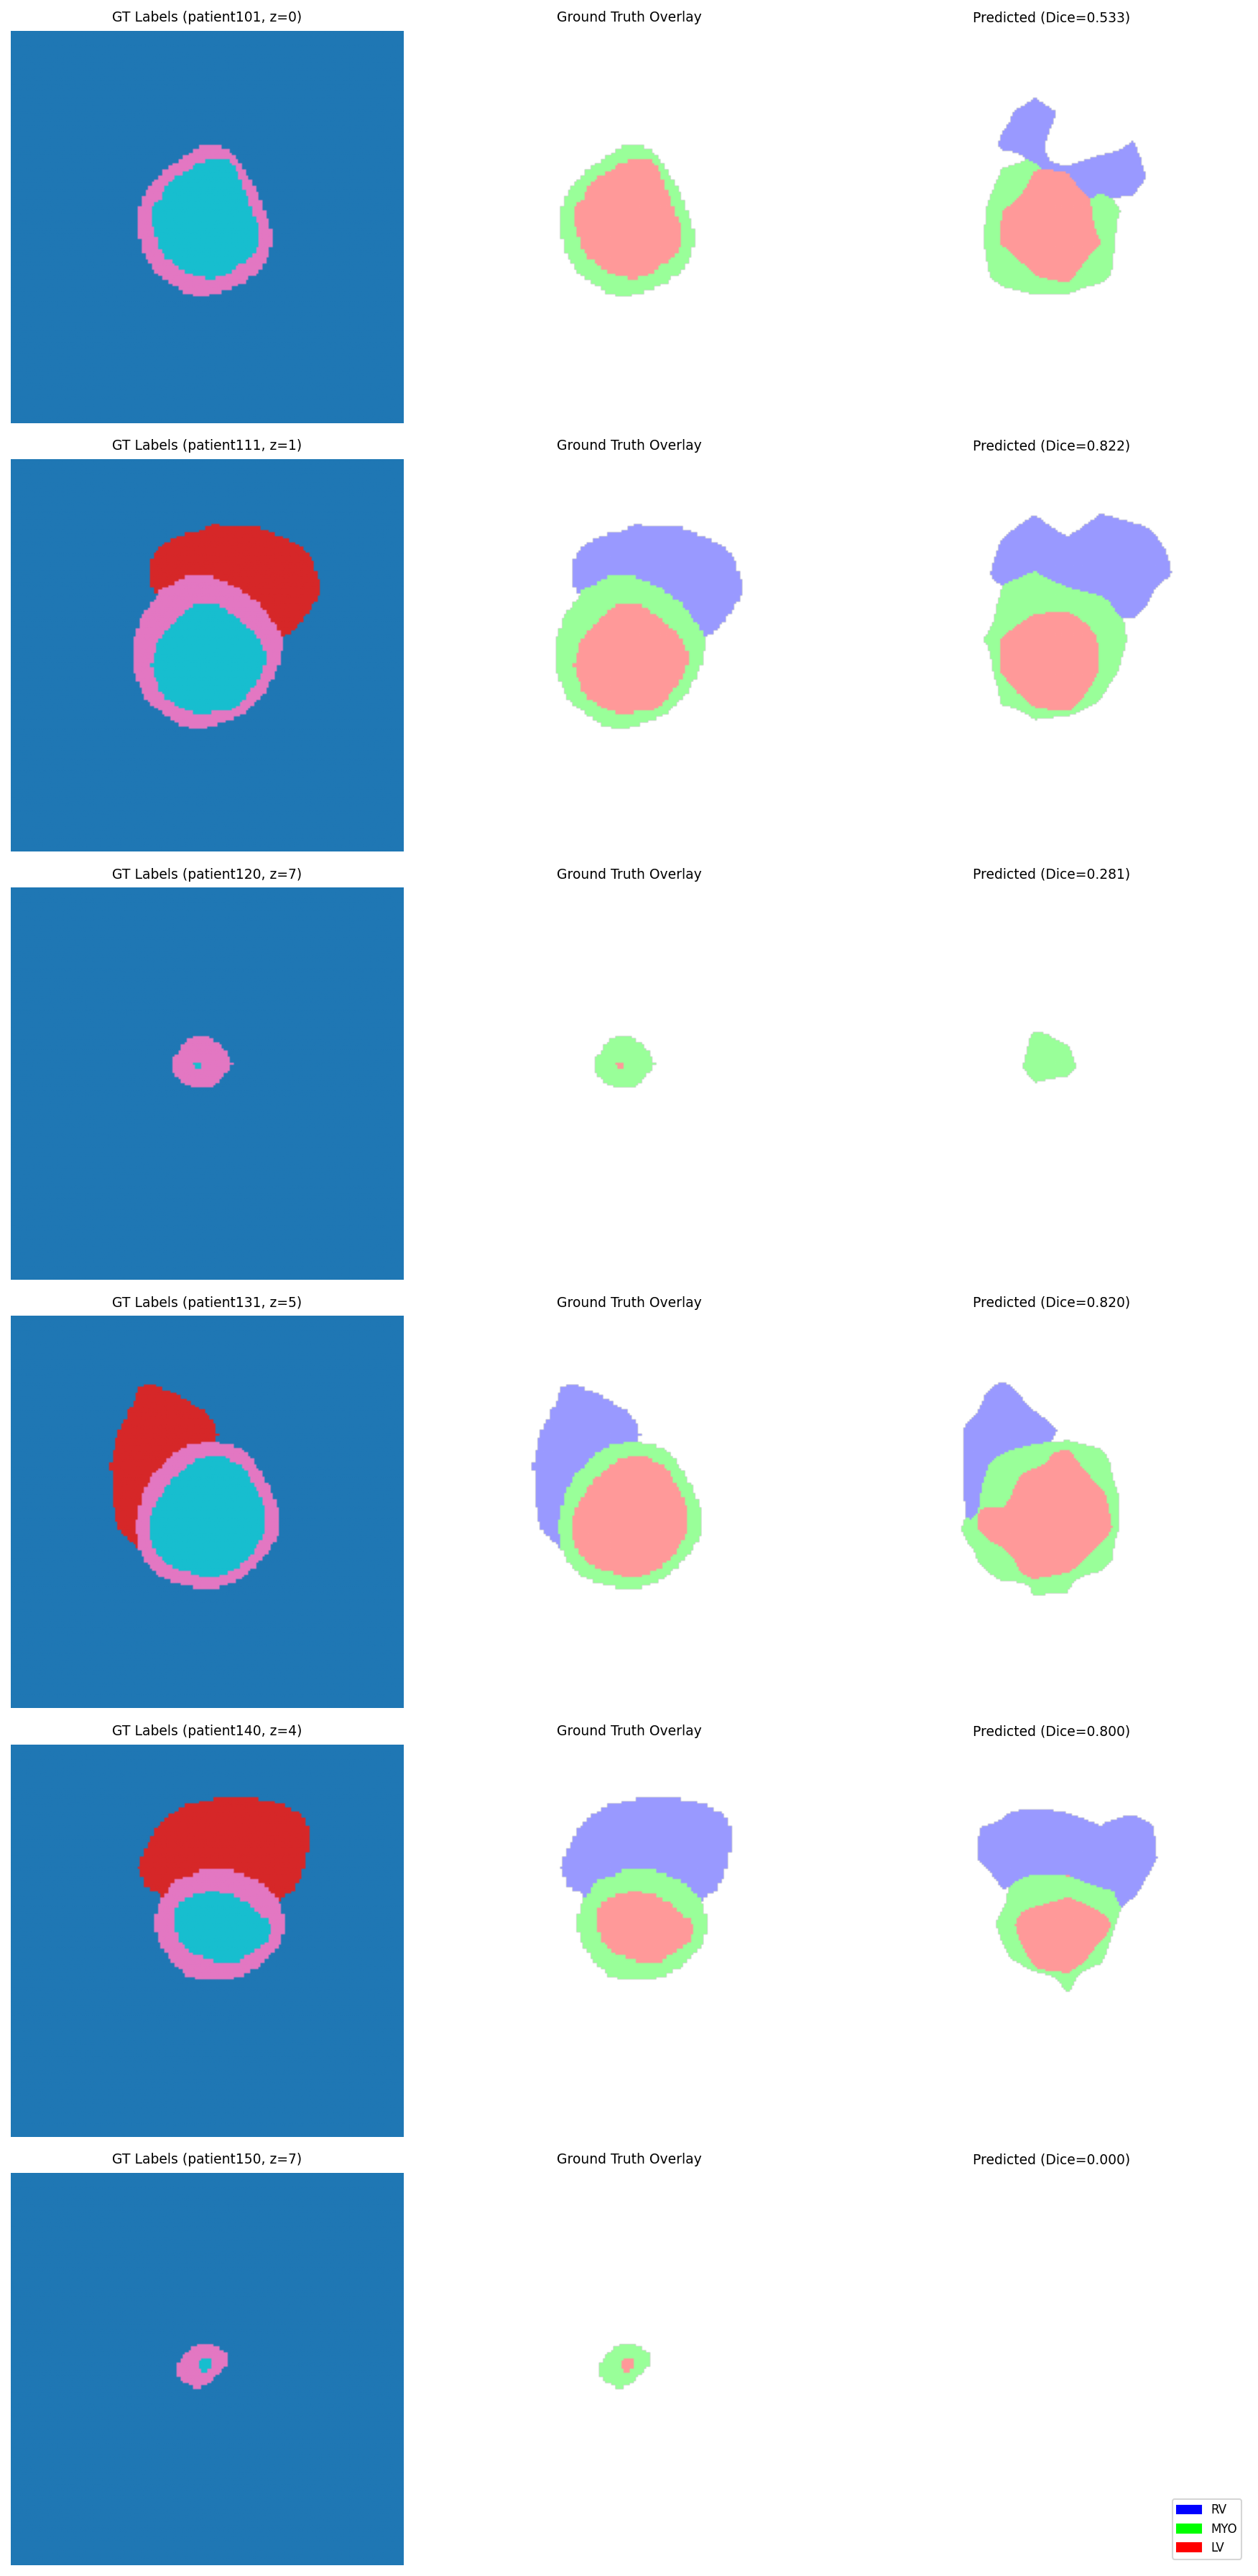

In [16]:
# Pick 6 evenly-spaced test slices for visualization
n_show = min(6, len(test_manifest))
show_indices = np.linspace(0, len(test_manifest) - 1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show), dpi=150)
if n_show == 1:
    axes = axes[np.newaxis, :]

probe.eval()
with torch.inference_mode():
    for row, idx in enumerate(show_indices):
        entry = test_manifest[idx]
        data = torch.load(entry["path"], weights_only=True)
        feats = data["features"].unsqueeze(0).to(DEVICE)
        label = data["label"].numpy()

        logits = probe(feats)
        pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        # Load original image for display
        # Reconstruct from the CineMA test dataset
        gt_overlay = overlay_labels(label, IMAGE_SIZE, IMAGE_SIZE)
        pred_overlay = overlay_labels(pred, IMAGE_SIZE, IMAGE_SIZE)

        # Show label as grayscale proxy (since cached features don't store raw image)
        axes[row, 0].imshow(label, cmap="tab10", vmin=0, vmax=3)
        axes[row, 0].set_title(f"GT Labels ({entry['pid']}, z={entry['z_idx']})", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(gt_overlay)
        axes[row, 1].set_title("Ground Truth Overlay", fontsize=9)
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_overlay)
        axes[row, 2].set_title(f"Predicted (Dice={compute_macro_dice(pred, label):.3f})", fontsize=9)
        axes[row, 2].axis("off")

legend_patches = [
    mpatches.Patch(color=CLASS_COLORS[c][:3] + (1.0,), label=CLASS_NAMES[c])
    for c in range(1, NUM_CLASSES)
]
axes[-1, 2].legend(handles=legend_patches, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Save Model

In [ ]:
save_path = Path(f"dense_probe_{MODEL_NAME}.pt")
torch.save(
    {
        "model_state_dict": probe.state_dict(),
        "model_name": MODEL_NAME,
        "embed_dim": EMBED_DIM,
        "layer_indices": LAYER_INDICES,
        "num_classes": NUM_CLASSES,
        "best_epoch": best_epoch,
        "best_val_dice": best_val_dice,
        "test_metrics": test_metrics,
        "val_pids": val_pids,
    },
    save_path,
)
print(f"Model saved to {save_path}")